
ANALYSE DES TRAJECTOIRES - TP3 FILTRE DE KALMAN

✓ Données chargées : 304 points

Affichage des visualisations...


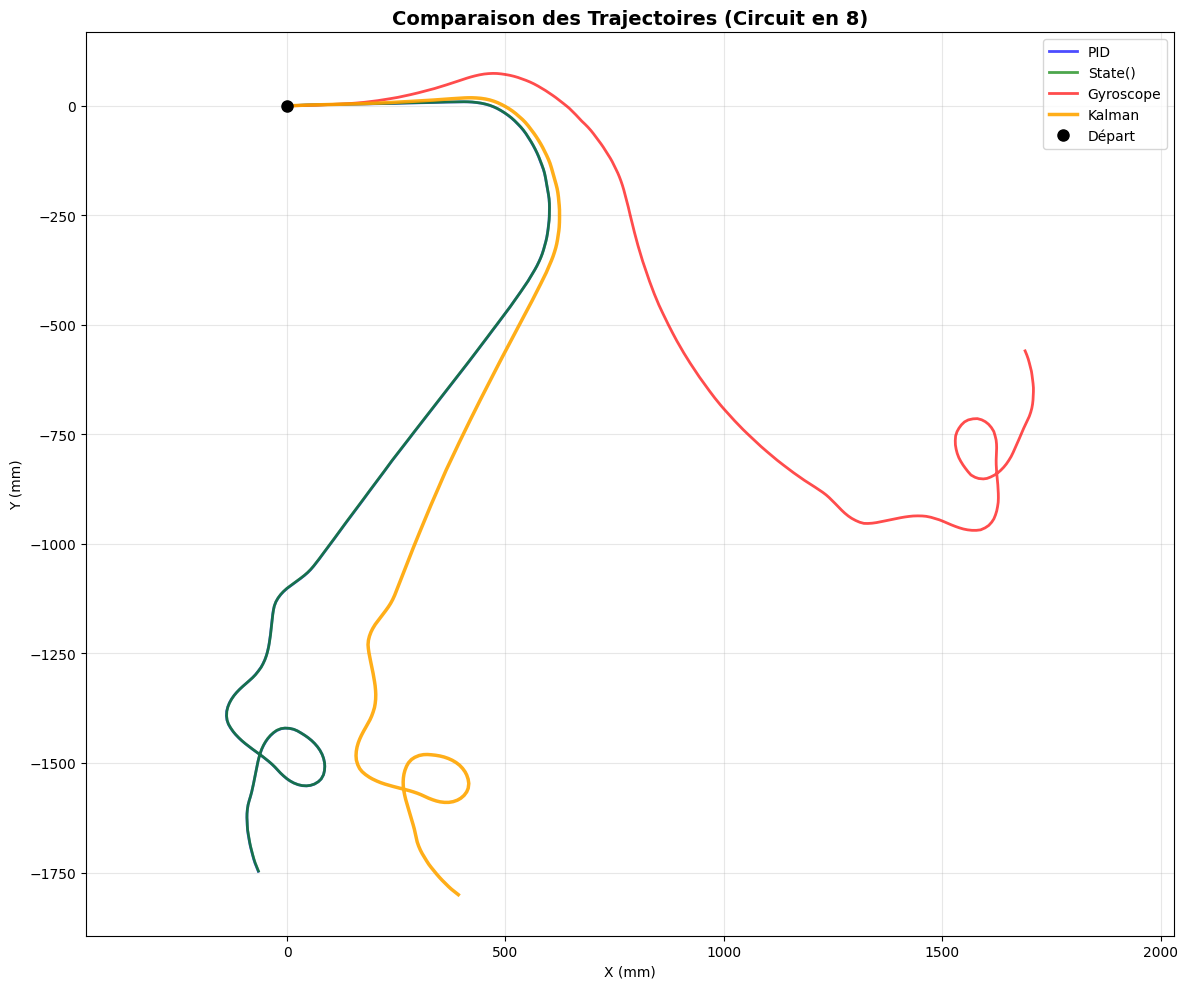

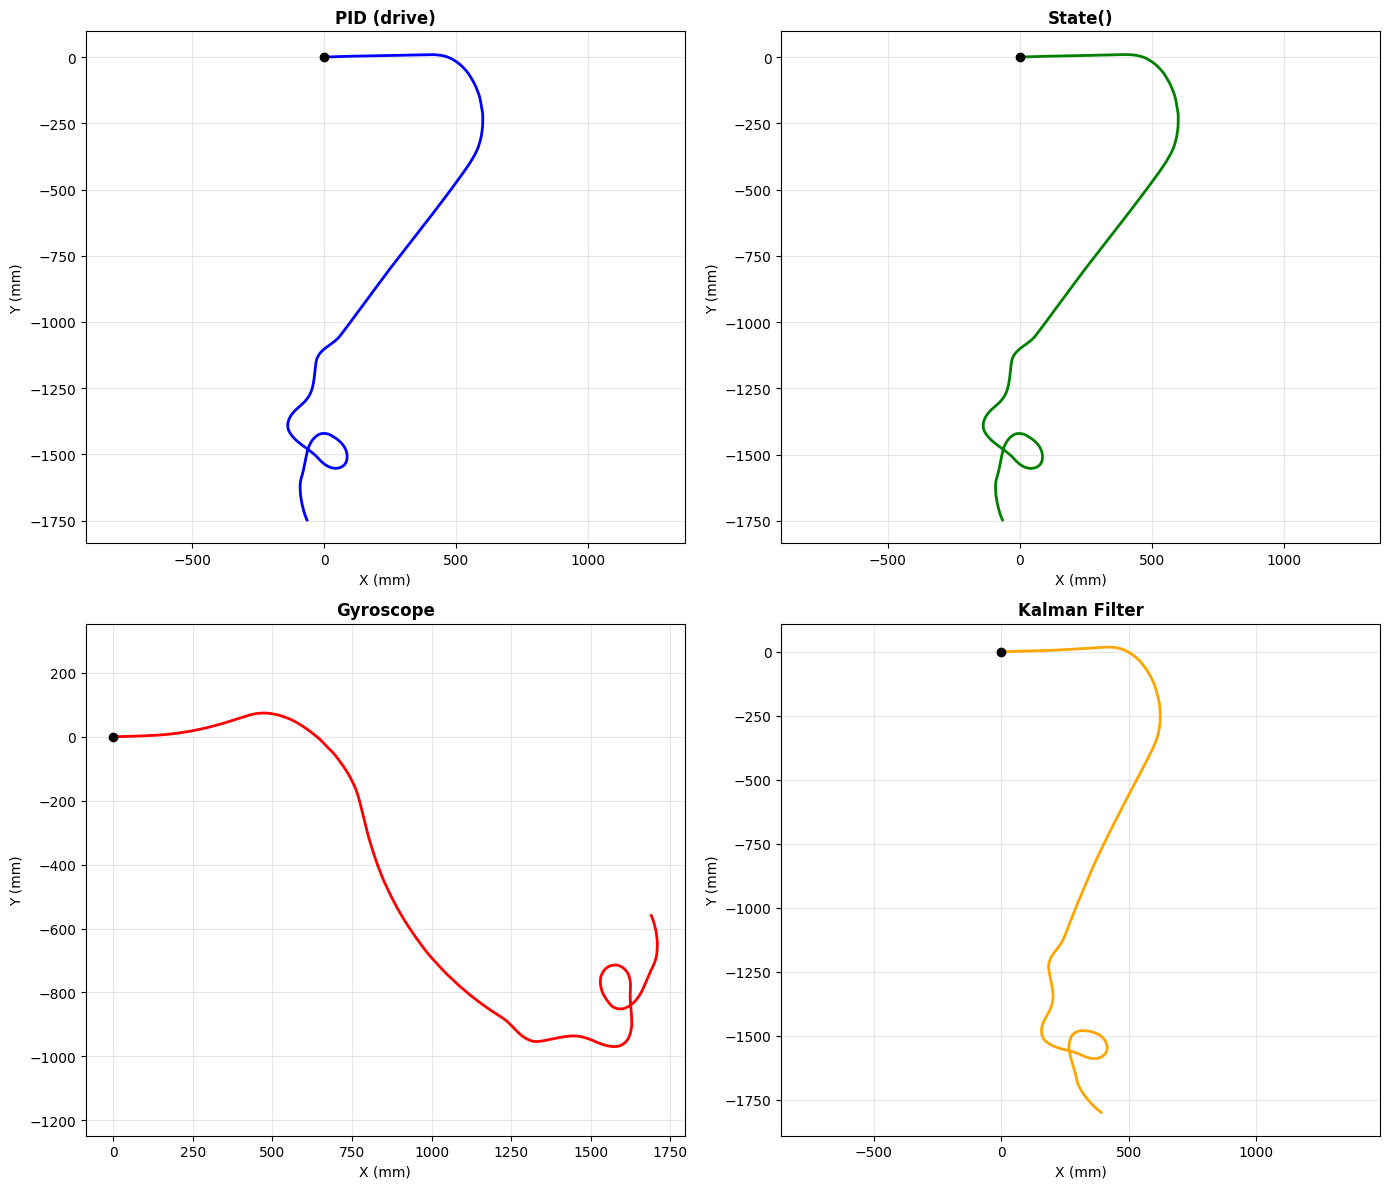

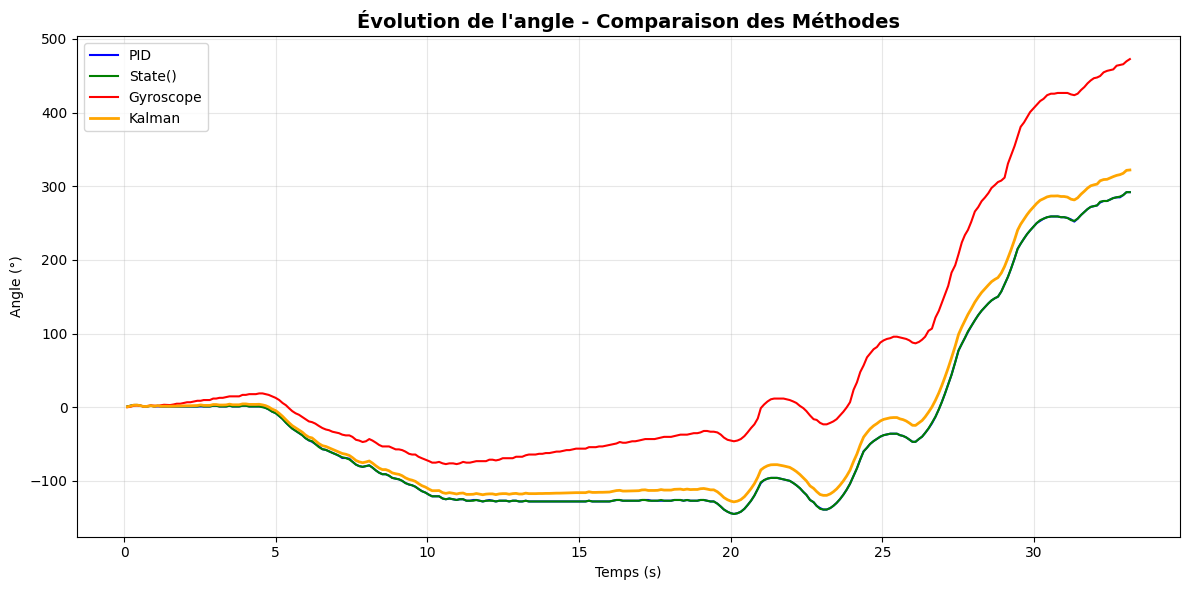

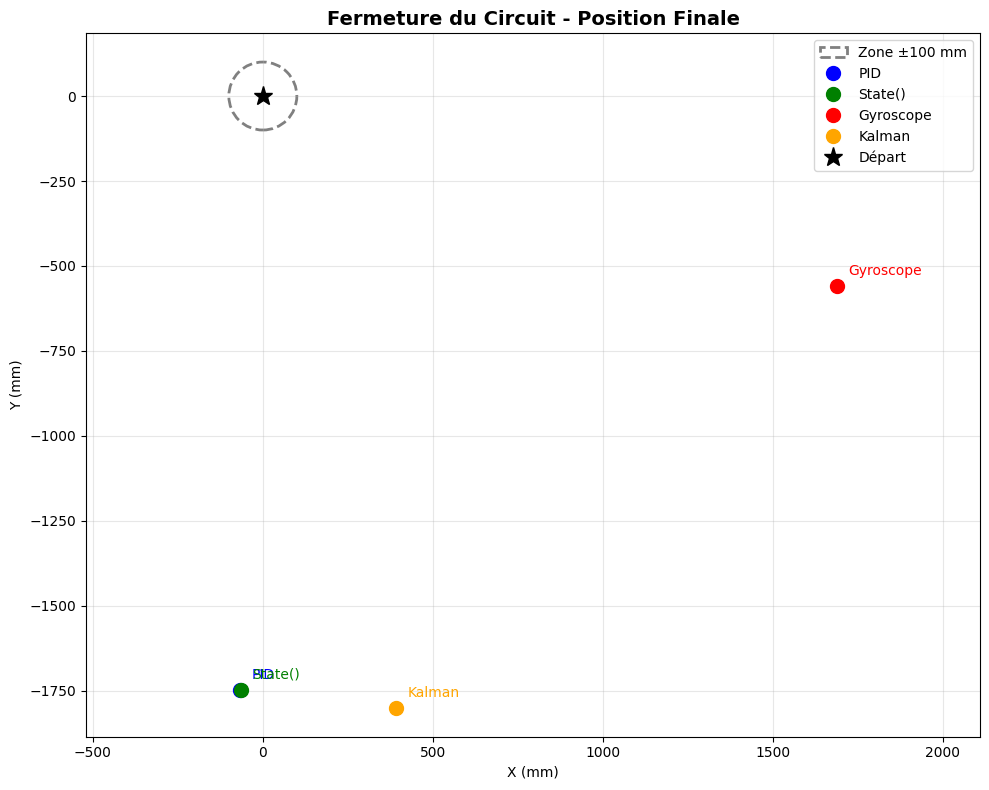

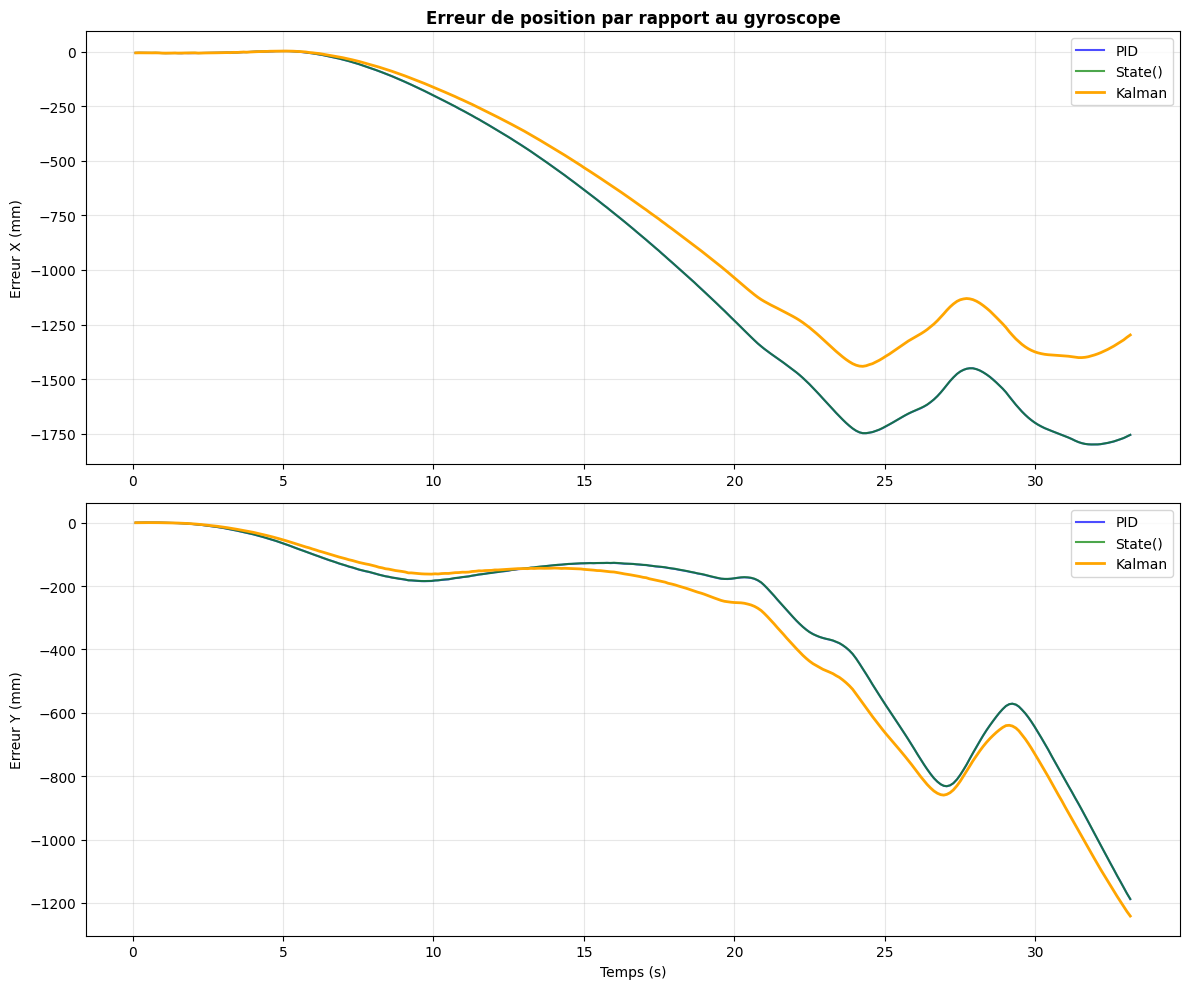

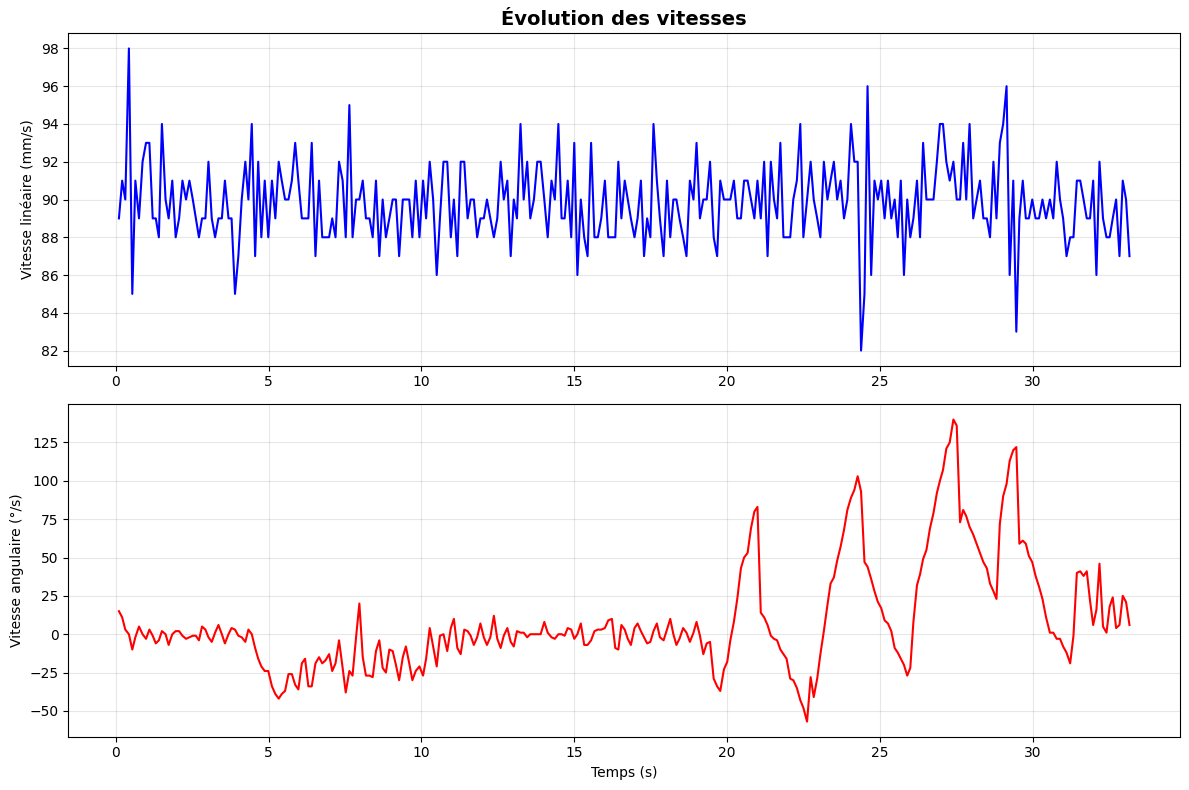


ANALYSE DES PERFORMANCES

PID:
  Distance totale parcourue : 2974.0 mm
  Erreur de fermeture (retour au départ) : 1748.4 mm

State():
  Distance totale parcourue : 2974.0 mm
  Erreur de fermeture (retour au départ) : 1747.8 mm

Gyroscope:
  Distance totale parcourue : 2969.5 mm
  Erreur de fermeture (retour au départ) : 1780.0 mm

Kalman:
  Distance totale parcourue : 2974.0 mm
  Erreur de fermeture (retour au départ) : 1842.8 mm


✓ Analyse terminée !


In [8]:
#!/usr/bin/env python3
"""
Analyse et visualisation des trajectoires du robot EV3 (TP3 - Filtre de Kalman)
UTBM MV55 - KOLANI, KOUNTA, NGUEMNIN
"""

import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

####################################################################################
# FONCTIONS UTILITAIRES
####################################################################################

def load_data(filename='kalman_D55.50000000000001_V108_Q0.05_R1.5_24_10_2025_2025_10_24_12_10_13_223598.csv'):
    """Charge et nettoie les données du fichier CSV généré par le robot"""
    try:
        # Lecture du fichier CSV (tabulation ou virgule)
        data = pd.read_csv(filename, sep=None, engine='python')
        print("✓ Données chargées :", len(data), "points")

        # Nettoyage des noms de colonnes
        data.columns = [c.strip().lower() for c in data.columns]

        # Conversion du temps en secondes
        if 'time' in data.columns:
            data['time'] = data['time'] / 1000.0

        return data

    except Exception as e:
        print("✗ Erreur de chargement :", e)
        return None


####################################################################################
# VISUALISATIONS
####################################################################################

def plot_all_trajectories(data):
    """Affiche toutes les trajectoires sur un même graphique"""
    fig, ax = plt.subplots(figsize=(12, 10))
    ax.plot(data['x_pid'], data['y_pid'], 'b-', label='PID', linewidth=2, alpha=0.7)
    ax.plot(data['x_state'], data['y_state'], 'g-', label='State()', linewidth=2, alpha=0.7)
    ax.plot(data['x_gyro'], data['y_gyro'], 'r-', label='Gyroscope', linewidth=2, alpha=0.7)
    ax.plot(data['x_kalman'], data['y_kalman'], color='orange', label='Kalman', linewidth=2.5, alpha=0.9)
    ax.plot(0, 0, 'ko', markersize=8, label='Départ')

    ax.set_xlabel('X (mm)')
    ax.set_ylabel('Y (mm)')
    ax.set_title('Comparaison des Trajectoires (Circuit en 8)', fontsize=14, fontweight='bold')
    ax.legend(fontsize=10)
    ax.grid(True, alpha=0.3)
    ax.axis('equal')
    plt.tight_layout()
    plt.show()


def plot_individual_trajectories(data):
    """Affiche chaque trajectoire séparément"""
    fig, axes = plt.subplots(2, 2, figsize=(14, 12))
    methods = [
        ('x_pid', 'y_pid', 'PID (drive)', 'blue'),
        ('x_state', 'y_state', 'State()', 'green'),
        ('x_gyro', 'y_gyro', 'Gyroscope', 'red'),
        ('x_kalman', 'y_kalman', 'Kalman Filter', 'orange')
    ]
    for idx, (x_col, y_col, title, color) in enumerate(methods):
        ax = axes[idx // 2, idx % 2]
        ax.plot(data[x_col], data[y_col], color=color, linewidth=2)
        ax.plot(0, 0, 'ko', markersize=6)
        ax.set_xlabel('X (mm)')
        ax.set_ylabel('Y (mm)')
        ax.set_title(title, fontsize=12, fontweight='bold')
        ax.grid(True, alpha=0.3)
        ax.axis('equal')
    plt.tight_layout()
    plt.show()


def plot_angles_comparison(data):
    """Compare l’évolution des angles pour chaque méthode"""
    fig, ax = plt.subplots(figsize=(12, 6))
    ax.plot(data['time'], data['theta_pid'], 'b-', label='PID', linewidth=1.5)
    ax.plot(data['time'], data['theta_state'], 'g-', label='State()', linewidth=1.5)
    ax.plot(data['time'], data['theta_gyro'], 'r-', label='Gyroscope', linewidth=1.5)
    ax.plot(data['time'], data['theta_kalman'], color='orange', label='Kalman', linewidth=2)
    ax.set_xlabel('Temps (s)')
    ax.set_ylabel('Angle (°)')
    ax.set_title("Évolution de l'angle - Comparaison des Méthodes", fontsize=14, fontweight='bold')
    ax.legend()
    ax.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()


def analyze_circuit_closure(data):
    """Analyse la fermeture du circuit (position finale de chaque méthode)"""
    fig, ax = plt.subplots(figsize=(10, 8))
    methods = [
        ('x_pid', 'y_pid', 'PID', 'blue'),
        ('x_state', 'y_state', 'State()', 'green'),
        ('x_gyro', 'y_gyro', 'Gyroscope', 'red'),
        ('x_kalman', 'y_kalman', 'Kalman', 'orange')
    ]
    circle = plt.Circle((0, 0), 100, color='gray', fill=False,
                        linestyle='--', linewidth=2, label='Zone ±100 mm')
    ax.add_patch(circle)

    for x_col, y_col, name, color in methods:
        fx, fy = data[x_col].iloc[-1], data[y_col].iloc[-1]
        ax.plot(fx, fy, 'o', color=color, markersize=10, label=name)
        ax.annotate(name, (fx, fy), xytext=(8, 8), textcoords='offset points',
                    fontsize=10, color=color)

    ax.plot(0, 0, 'k*', markersize=14, label='Départ')
    ax.set_xlabel('X (mm)')
    ax.set_ylabel('Y (mm)')
    ax.set_title('Fermeture du Circuit - Position Finale', fontsize=14, fontweight='bold')
    ax.legend()
    ax.grid(True, alpha=0.3)
    ax.axis('equal')
    plt.tight_layout()
    plt.show()


def plot_error_evolution(data):
    """Compare les erreurs de position par rapport au gyroscope"""
    fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 10))
    ax1.plot(data['time'], data['x_pid'] - data['x_gyro'], 'b-', label='PID', alpha=0.7)
    ax1.plot(data['time'], data['x_state'] - data['x_gyro'], 'g-', label='State()', alpha=0.7)
    ax1.plot(data['time'], data['x_kalman'] - data['x_gyro'], color='orange', label='Kalman', linewidth=2)
    ax1.set_ylabel('Erreur X (mm)')
    ax1.set_title("Erreur de position par rapport au gyroscope", fontsize=12, fontweight='bold')
    ax1.legend()
    ax1.grid(True, alpha=0.3)

    ax2.plot(data['time'], data['y_pid'] - data['y_gyro'], 'b-', label='PID', alpha=0.7)
    ax2.plot(data['time'], data['y_state'] - data['y_gyro'], 'g-', label='State()', alpha=0.7)
    ax2.plot(data['time'], data['y_kalman'] - data['y_gyro'], color='orange', label='Kalman', linewidth=2)
    ax2.set_xlabel('Temps (s)')
    ax2.set_ylabel('Erreur Y (mm)')
    ax2.legend()
    ax2.grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()


def plot_velocities(data):
    """Affiche les vitesses linéaire et angulaire en fonction du temps"""
    fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 8))

    if 'velocity' in data.columns:
        ax1.plot(data['time'], data['velocity'], 'b-', linewidth=1.5)
        ax1.set_ylabel('Vitesse linéaire (mm/s)')
        ax1.set_title("Évolution des vitesses", fontsize=14, fontweight='bold')
        ax1.grid(True, alpha=0.3)

    if 'turn_rate' in data.columns:
        ax2.plot(data['time'], data['turn_rate'], 'r-', linewidth=1.5)
        ax2.set_xlabel('Temps (s)')
        ax2.set_ylabel('Vitesse angulaire (°/s)')
        ax2.grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()


####################################################################################
# ANALYSE NUMÉRIQUE
####################################################################################

def calculate_metrics(data):
    """Calcule quelques métriques simples pour chaque méthode"""
    print("\n" + "="*60)
    print("ANALYSE DES PERFORMANCES")
    print("="*60)
    methods = {
        'PID': ('x_pid', 'y_pid'),
        'State()': ('x_state', 'y_state'),
        'Gyroscope': ('x_gyro', 'y_gyro'),
        'Kalman': ('x_kalman', 'y_kalman')
    }

    for name, (x_col, y_col) in methods.items():
        dx = np.diff(data[x_col])
        dy = np.diff(data[y_col])
        total_distance = np.sum(np.sqrt(dx**2 + dy**2))
        fx, fy = data[x_col].iloc[-1], data[y_col].iloc[-1]
        closure_error = np.sqrt(fx**2 + fy**2)
        print(f"\n{name}:")
        print(f"  Distance totale parcourue : {total_distance:.1f} mm")
        print(f"  Erreur de fermeture (retour au départ) : {closure_error:.1f} mm")
    print("\n" + "="*60)


####################################################################################
# MAIN
####################################################################################

def main():
    print("\n" + "="*60)
    print("ANALYSE DES TRAJECTOIRES - TP3 FILTRE DE KALMAN")
    print("="*60 + "\n")

    data = load_data()
    if data is None:
        print("✗ Impossible de charger le fichier CSV.")
        return

    print("\nAffichage des visualisations...")
    plot_all_trajectories(data)
    plot_individual_trajectories(data)
    plot_angles_comparison(data)
    analyze_circuit_closure(data)
    plot_error_evolution(data)
    plot_velocities(data)
    calculate_metrics(data)

    print("\n✓ Analyse terminée !")


####################################################################################

if __name__ == "__main__":
    main()
